# Dataset

Dataset: https://www.kaggle.com/datasets/muhammedderric/fitness-classification-dataset-synthetic?select=fitness_dataset.csv

## Lista de Variables

**age**: Edad del individuo en años.
**height_cm**: Altura en centímetros.
**weight_kg**: Peso en kilogramos.
**heart_rate**: Frecuencia cardíaca en reposo en latidos por minuto.
**blood_pressure**: Presión arterial sistólica en mmHg.
**sleep_hours**: Promedio de horas de sueño al día.
**nutrition_quality**: Puntuación de calidad nutricional diaria entre 0 y 10.
**activity_index**: Puntuación del nivel de actividad física entre 1 y 5.
**smokes**: ¿fuma?
**gender**: Género del individuo.
**is_fit**: Variable objetivo (la persona está en forma o no).

## Preprocesamiento

### Librerías

In [1]:
import pandas as pd
import kagglehub
import os
import kagglehub
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from scipy.stats import shapiro
import matplotlib.pyplot as plt
from scipy.stats import ks_2samp
from scipy.stats import skew, kurtosis

print("Librerías importadas correctamente")

c:\Users\johan\miniconda3\envs\ml_venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Librerías importadas correctamente


### Lectura de Datos

In [2]:
path = kagglehub.dataset_download("muhammedderric/fitness-classification-dataset-synthetic")

print("Path to dataset files:", path)

downloaded_files = os.listdir(path)

print("Archivos disponibles:", downloaded_files)

csv_path = os.path.join(path, "fitness_dataset.csv") 

df = pd.read_csv(csv_path)

Path to dataset files: C:\Users\johan\.cache\kagglehub\datasets\muhammedderric\fitness-classification-dataset-synthetic\versions\1
Archivos disponibles: ['dataset-metadata.json', 'fitness_dataset.csv', 'README.md']


Se muestran las 5 primeras filas del DataFrame.

In [3]:
df.head()

,age,height_cm,weight_kg,heart_rate,blood_pressure,sleep_hours,nutrition_quality,activity_index,smokes,gender,is_fit
0,56,152,65,69.6,117.0,NaN,2.37,3.97,no,F,1
1,69,186,95,60.8,114.8,7.5,8.77,3.19,0,F,1
2,46,192,103,61.4,116.4,NaN,8.20,2.03,0,F,0
3,32,189,83,60.2,130.1,7.0,6.18,3.68,0,M,1
4,60,175,99,58.1,115.8,8.0,9.95,4.83,yes,F,1


Se muestran las 5 últimas filas del DataFrame.

In [4]:
df.tail()

,age,height_cm,weight_kg,heart_rate,blood_pressure,sleep_hours,nutrition_quality,activity_index,smokes,gender,is_fit
1995,52,173,98,60.7,106.1,NaN,1.54,3.25,1,M,1
1996,61,186,74,51.4,123.8,9.4,8.63,3.15,no,M,1
1997,77,198,89,76.7,103.6,8.3,1.98,3.36,yes,M,0
1998,62,190,63,80.7,115.9,6.7,9.21,2.39,1,F,0
1999,51,166,78,89.3,101.8,8.3,4.42,1.02,1,M,0


Se presenta un resumen detallado de todas las variables del dataset, incluyendo el tipo de dato (entero, punto flotante o carácter) lo que permite evaluar la integridad y estructura de los datos para su posterior procesamiento.

In [5]:
print("Número de observaciones (filas):", df.shape[0])
print("Número de variables (columnas):", df.shape[1])

print(df.dtypes)

Número de observaciones (filas): 2000
Número de variables (columnas): 11
age                    int64
height_cm              int64
weight_kg              int64
heart_rate           float64
blood_pressure       float64
sleep_hours          float64
nutrition_quality    float64
activity_index       float64
smokes                object
gender                object
is_fit                 int64
dtype: object


#### Interpretación del Dataset:

El dataset presentado contiene 2,000 observaciones y 11 variables, que incluyen una combinación de tipos de datos numéricos (enteros y decimales) y de tipo carácter.

Las variables numéricas abarcan características como edad **age**, **altura height_cm**, peso **weight_kg**, frecuencia cardíaca **heart_rate**, presión arterial **blood_pressure**, horas de sueño **sleep_hours**, calidad de nutrición **nutrition_quality** e índice de actividad **activity_index**.

Las variables cualitativas son **smokes** hábito de fumar y **gender** género, mientras que la variable objetivo **is_fit** (indicador binario de condición física) está codificada como entero.

#### Datos Faltantes

Se calcula el número de valores faltantes para cada variable del DataFrame.

In [6]:
df.isna().sum()

age                    0
height_cm              0
weight_kg              0
heart_rate             0
blood_pressure         0
sleep_hours          160
nutrition_quality      0
activity_index         0
smokes                 0
gender                 0
is_fit                 0
dtype: int64

In [7]:
col = "sleep_hours"
porcentaje_na = df[col].isna().mean() * 100
print(f"La variable '{col}' tiene {porcentaje_na:.2f}% de valores faltantes.")


La variable 'sleep_hours' tiene 8.00% de valores faltantes.


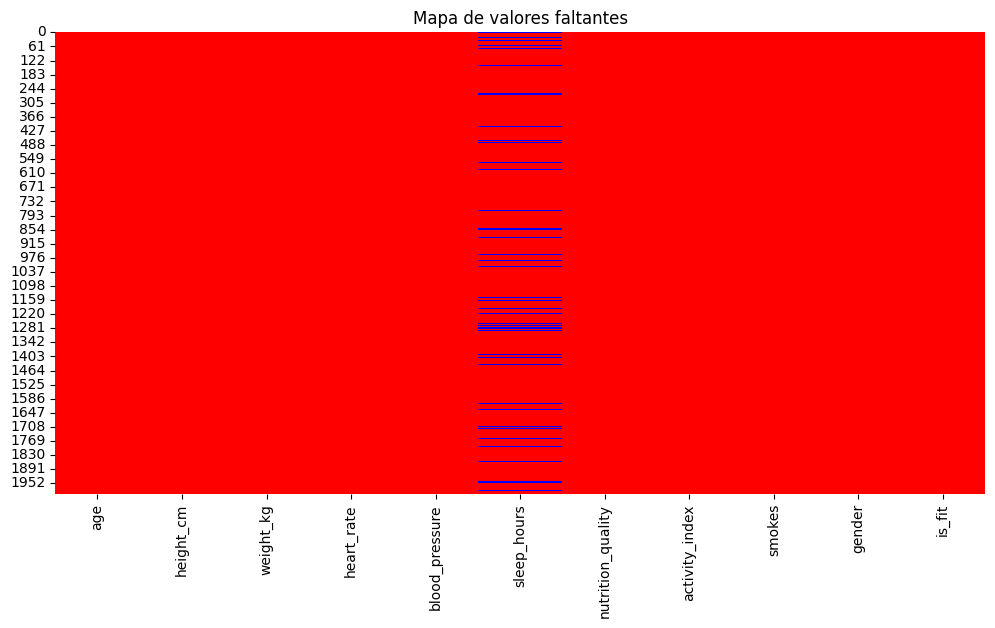

In [8]:
plt.figure(figsize=(12,6))
sns.heatmap(df.isna(), cbar=False, cmap=["red", "blue"])
plt.title("Mapa de valores faltantes")
plt.show()

#### Interpretación de los Valores Faltantes:

El análisis de valores faltantes en el dataset revela que la variable sleep_hours presenta 160 NA (8% del total de observaciones de esa columna), lo que indica una proporción significativa de datos ausentes que podría afectar los análisis relacionados con patrones de sueño.

El resto de las variables, incluyendo indicadores de salud como presión arterial (blood_pressure), calidad nutricional (nutrition_quality), y variables demográficas como género (gender), no contienen valores faltantes.

Esta estructura sugiere que el dataset está mayormente completo, excepto por la variable de sueño.

## Tratamiento de datos faltantes

Como nuestra variable tiene un porcentaje de datos faltantes de 8%, podemos imputar por la media (en caso de que siga una distribución normal) o mediana (si no tiene una distribución normal). Antes de realizar la imputacion vamos a revisar la normalidad de nuestros datos para saber que metodo vamos a utilizar.


In [9]:
df_antes = df

In [10]:
stat, p = shapiro(df_antes["sleep_hours"])

print("Prueba de Shapiro-Wilk para 'sleep_hour' despues de imputación")
print("Estadístico W:", stat)
print("p-valor:", p)

if p > 0.05:
    print("No se rechaza H0: la variable parece provenir de una distribución normal.")
else:
    print("Se rechaza H0: la variable no sigue una distribución normal.")

Prueba de Shapiro-Wilk para 'sleep_hour' despues de imputación
Estadístico W: nan
p-valor: 1.0
No se rechaza H0: la variable parece provenir de una distribución normal.


Como el p-valor obtenido es 0.0003277<0.05, se rechaza la hipotesis nula de que nuestro conjunto de datos es normal, por lo que debemos realizar la imputación por medio de la mediana como se hizo anteriormente.

La mediana de horas de sueño es: 7.50
Cantidad de valores faltantes en 'sleep_hour' antes de imputar: 160


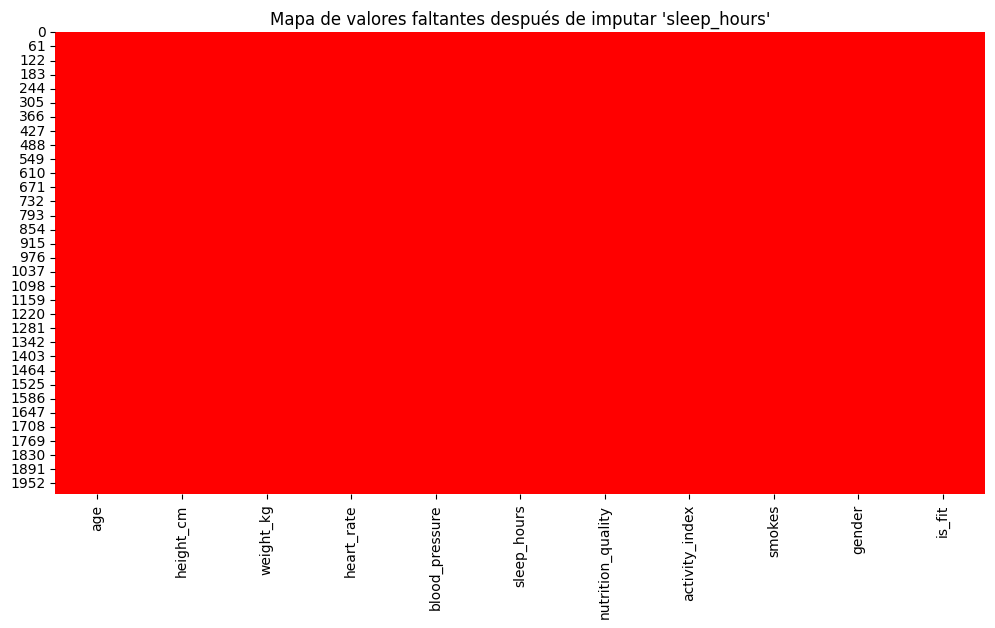

In [11]:
median_sleep = np.nanmedian(df["sleep_hours"])
print(f"La mediana de horas de sueño es: {median_sleep:.2f}")

na_count_before = df["sleep_hours"].isna().sum()
print(f"Cantidad de valores faltantes en 'sleep_hour' antes de imputar: {na_count_before}")

df["sleep_hours"] = df["sleep_hours"].fillna(median_sleep)

# 3. Visualizar nuevamente el mapa de valores faltantes
plt.figure(figsize=(12,6))
sns.heatmap(df.isna(), cbar=False, cmap=["red", "blue"])
plt.title("Mapa de valores faltantes después de imputar 'sleep_hours'")
plt.show()


### Análisis de Conservación de la Distribución Post-Imputación

Realizaremos un histograma y una prueba no parametrica (debido a que no es normal) para ver si luego de hacer la imputación de los datos se mantiene la distribucion.

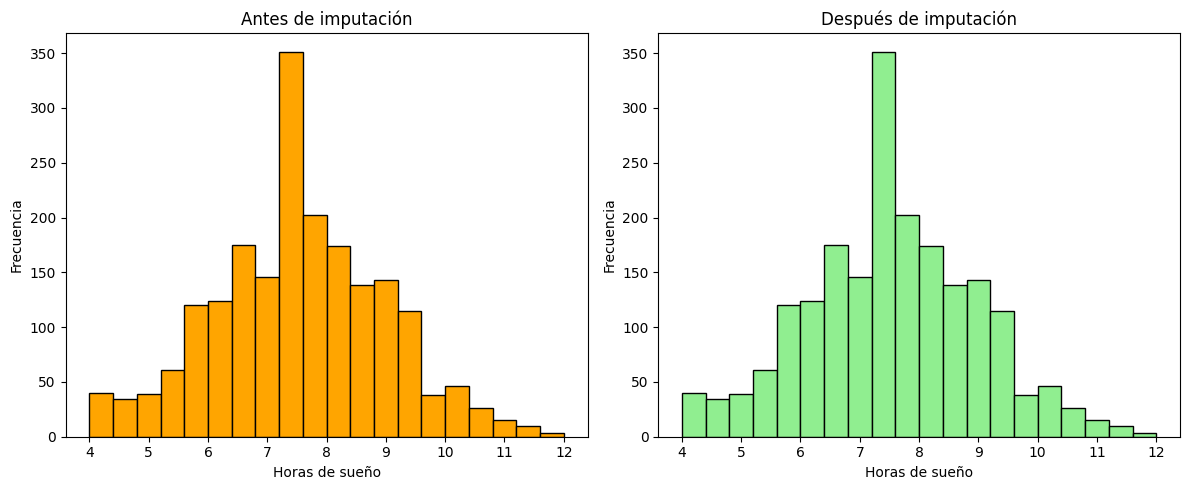

In [12]:

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Histograma antes de imputación
axes[0].hist(df_antes["sleep_hours"].dropna(), bins=20, color="orange", edgecolor="black")
axes[0].set_title("Antes de imputación")
axes[0].set_xlabel("Horas de sueño")
axes[0].set_ylabel("Frecuencia")

# Histograma después de imputación
axes[1].hist(df["sleep_hours"], bins=20, color="lightgreen", edgecolor="black")
axes[1].set_title("Después de imputación")
axes[1].set_xlabel("Horas de sueño")
axes[1].set_ylabel("Frecuencia")

plt.tight_layout()
plt.show()


### Prueba no Parametrica para **Sleep_hours** - Mediana

Para evaluar si la imputación mantuvo la forma original de la distribución de las variables, se emplea la prueba de Kolmogorov–Smirnov, la cual permite comparar estadísticamente dos muestras y determinar si provienen de la misma distribución.

Hipótesis nula: ambas muestras provienen de la misma distribución.

Hipótesis alternativa: las muestras provienen de distribuciones diferentes.

In [13]:
sleep_before = df_antes["sleep_hours"]
sleep_after  = df["sleep_hours"]

# Prueba KS de dos muestras
stat, p = ks_2samp(sleep_before, sleep_after)

print("Prueba de Kolmogorov-Smirnov para 'sleep_hour'")
print("Estadístico KS:", stat)
print("p-valor:", p)


Prueba de Kolmogorov-Smirnov para 'sleep_hour'
Estadístico KS: 0.0
p-valor: 1.0


Como el p-valor es mayor que el nivel de significancia, no hay evidencia significativa para rechazar H_0, por lo que ambas muestras provienen de la misma distribución, esto es, despues de la imputación no se afecto la distribución.

---

Se calcula el número de valores únicos para cada variable del DataFrame.

In [14]:
df.nunique()

age                   62
height_cm             50
weight_kg             80
heart_rate           484
blood_pressure       563
sleep_hours           79
nutrition_quality    866
activity_index       398
smokes                 4
gender                 2
is_fit                 2
dtype: int64

#### Interpretación de los Valores únicos:

Variables continuas: heart_rate (484 únicos), blood_pressure (563), nutrition_quality (866) y activity_index (398) presentan alta granularidad, lo que sugiere mediciones precisas o decimales. sleep_hours (79 únicos) también refleja variabilidad, aunque con menos detalle.

Variables discretas: age (62 únicos), height_cm (50) y weight_kg (80) indican rangos demográficos y físicos esperados en una muestra de 2,000 observaciones.

Variables categóricas: smokes tiene 4 categorías (posiblemente incluyendo errores), gender y is_fit son binarias (2 únicos cada una), lo que confirma su naturaleza dicotómica.

La variable smokes tiene 4 valores únicos, lo cual es inesperado, ya que se espera que sea una variable binaria que represente si una persona fuma o no. Entonces, se identifican los valores inesperados.

In [15]:
df["smokes"].unique()


array(['no', '0', 'yes', '1'], dtype=object)

Se estandarizan las variables smokes e is_fit para mejorar la legibilidad y la coherencia de los datos.

La variable is_fit se encontraba codificada con los valores 0 y 1, que se reemplazan por “no” y “yes”, respectivamente, para hacerla más comprensible.

La variable smokes contenía cuatro valores únicos: 0, 1, “no” y “yes”. Para consolidar esta información y evitar errores en el análisis, se unifican todos los valores a dos categorías: 0 se reemplaza por “no” y 1 por “yes”.

In [16]:
df["smokes"] = df["smokes"].replace({"0": "no", "1": "yes"})

df["is_fit"] = df["is_fit"].replace({0: "no", 1: "yes"})

ejecutamos nuevamente para ver los valores unicos de la variable **smokes**

In [17]:
df["smokes"].unique()

array(['no', 'yes'], dtype=object)

En efecto, vemos que ya quedo codificada de forma correcta

## Analisis de Datos Atipicos
Aplicaremos la técnica de capping basada en percentiles para atenuar el efecto de valores atípicos extremos, reemplazándolos por los límites de los cuartiles y preservando así la estructura general de los datos sin eliminarlos.

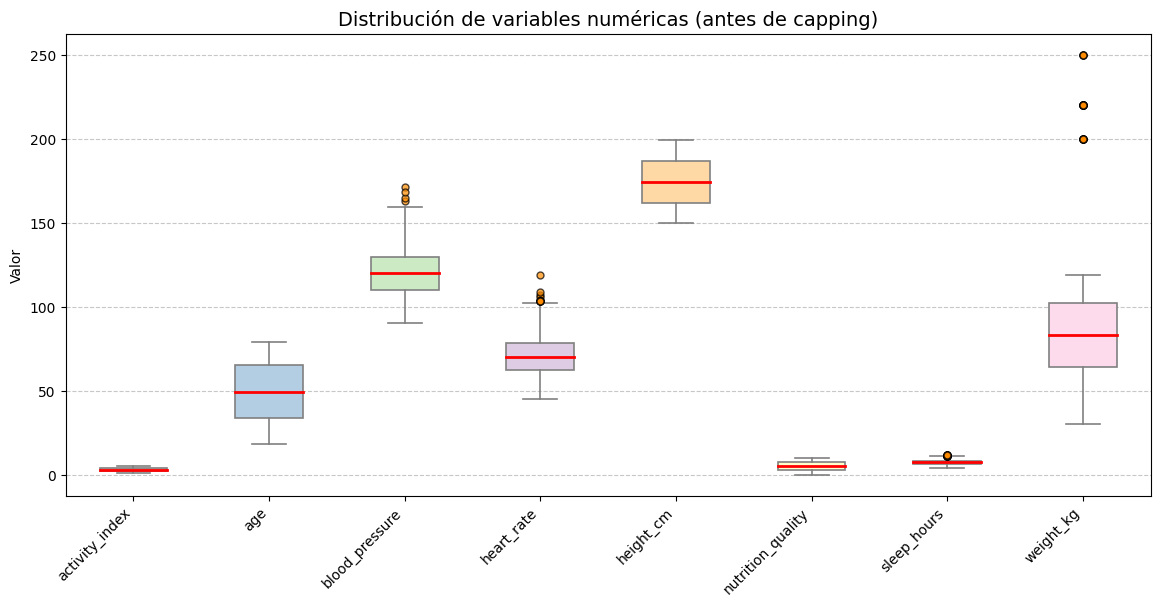

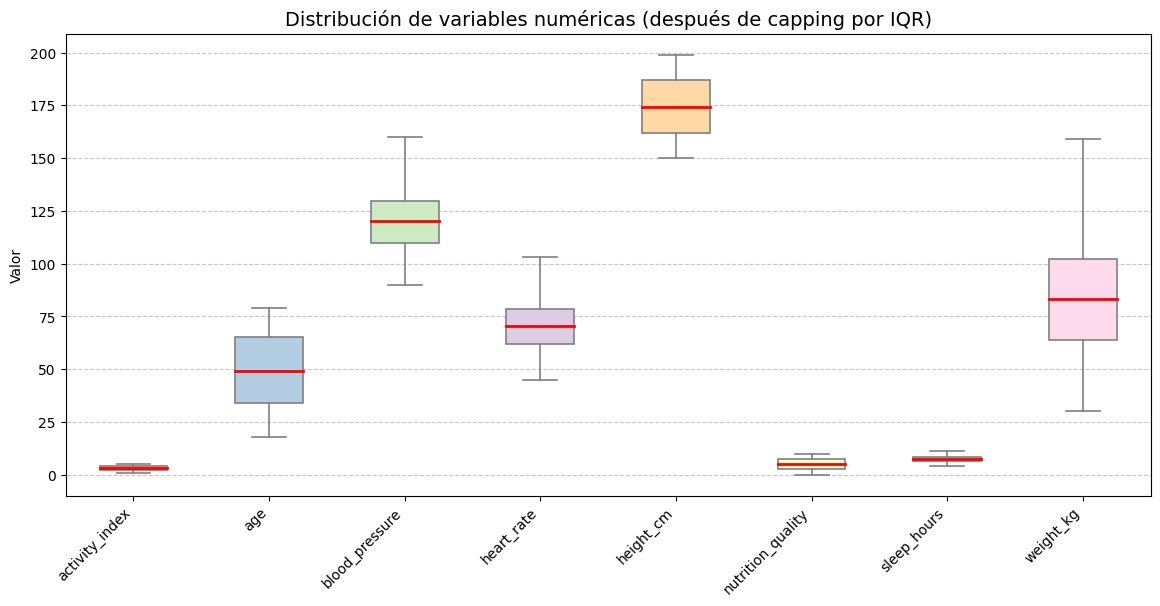

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def capping_iqr(x):
    Q1 = np.nanpercentile(x, 25)
    Q3 = np.nanpercentile(x, 75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return np.clip(x, lower, upper)

variables_predictores = df.columns.difference(["is_fit"])

variables_numericas = [col for col in variables_predictores if pd.api.types.is_numeric_dtype(df[col])]

# BOXPLOTS ANTES DE CAPPING
plt.figure(figsize=(14, 6))

box = plt.boxplot(
    [df[col].dropna() for col in variables_numericas],
    patch_artist=True,
    labels=variables_numericas,
    medianprops=dict(color="red", linewidth=2),
    whiskerprops=dict(color="gray", linewidth=1.2),
    capprops=dict(color="gray", linewidth=1.2),
    boxprops=dict(linewidth=1.2, color="gray"),
    flierprops=dict(marker="o", markerfacecolor="darkorange", markeredgecolor="black",
                    alpha=0.7, markersize=5)  # OUTLIERS resaltados
)

colors = plt.cm.Pastel1.colors  
for patch, color in zip(box['boxes'], colors):
    patch.set_facecolor(color)

plt.xticks(rotation=45, ha="right")
plt.title("Distribución de variables numéricas (antes de capping)", fontsize=14)
plt.ylabel("Valor")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

# APLICAR CAPPING
for col in variables_numericas:
    df[col] = capping_iqr(df[col])

# BOXPLOTS DESPUÉS DE CAPPING
plt.figure(figsize=(14, 6))

box2 = plt.boxplot(
    [df[col].dropna() for col in variables_numericas],
    patch_artist=True,
    labels=variables_numericas,
    medianprops=dict(color="red", linewidth=2),
    whiskerprops=dict(color="gray", linewidth=1.2),
    capprops=dict(color="gray", linewidth=1.2),
    boxprops=dict(linewidth=1.2, color="gray"),
    flierprops=dict(marker="o", markerfacecolor="lightgray", markeredgecolor="gray",
                    alpha=0.5, markersize=4) 
)

for patch, color in zip(box2['boxes'], colors):
    patch.set_facecolor(color)

plt.xticks(rotation=45, ha="right")
plt.title("Distribución de variables numéricas (después de capping por IQR)", fontsize=14)
plt.ylabel("Valor")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

Tras aplicar el capping, los boxplots muestran una distribución más uniforme y sin valores atípicos extremos, lo que facilita un análisis más estable y representativo de las variables.

# Analisis univariado

El Análisis Univariado es la primera fase del análisis exploratorio de datos. Se enfoca en el estudio individual de cada variable para entender su distribución, características y valores atípicos. Esto permite identificar patrones y la calidad de los datos antes de un análisis más complejo.

## Variables Binarias

Se genera un doble gráfico para cada variable binaria, permitiendo comparar su distribución mediante:

- Gráfico de barras: Muestra el conteo absoluto de cada categoría (0 y 1). Ideal para comparar magnitudes visualmente.

- Gráfico de Torta: Muestra la proporción porcentual de cada categoría. Útil para entender el balance/imbalance entre clases.

c:\Users\johan\miniconda3\envs\ml_venv\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\johan\miniconda3\envs\ml_venv\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\johan\miniconda3\envs\ml_venv\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\johan\miniconda3\envs\ml_venv\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(d

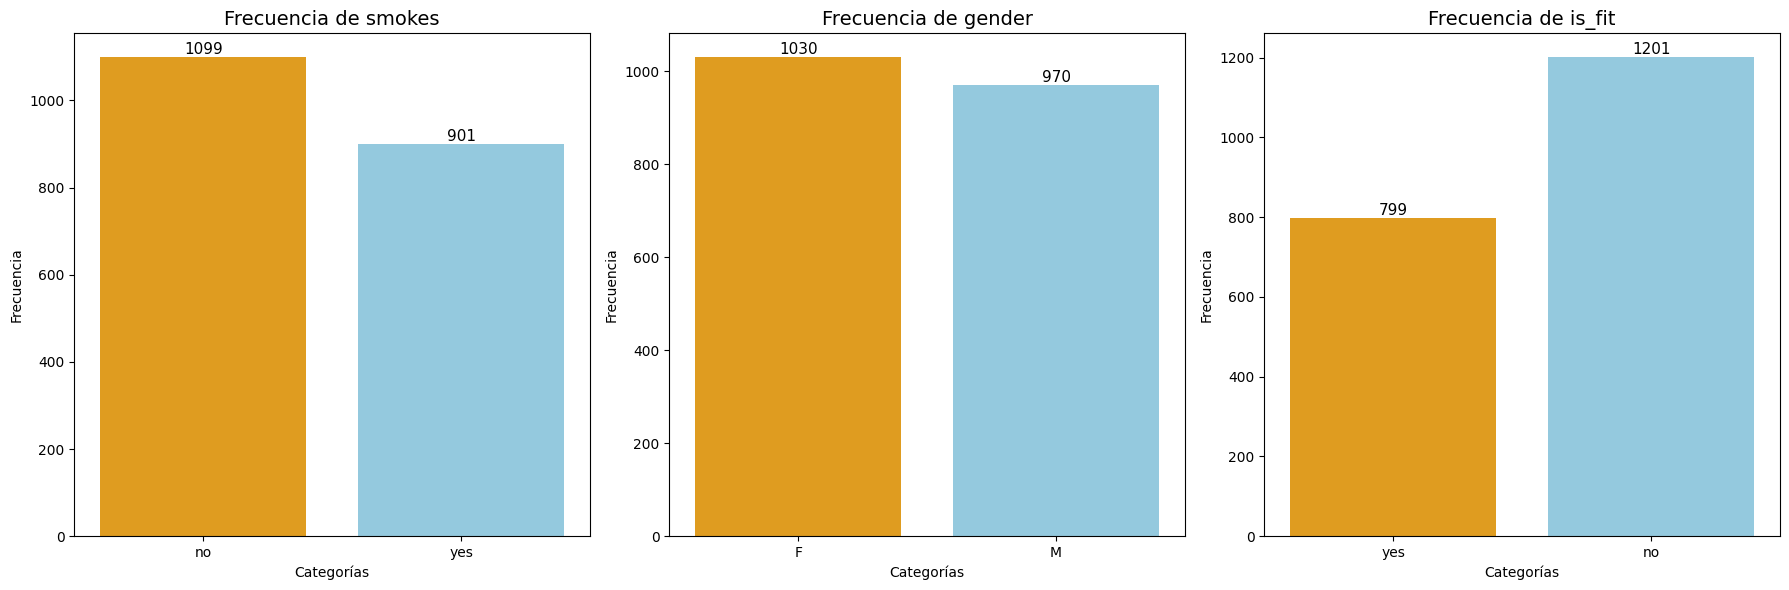

In [19]:
colors = ["orange", "skyblue"]

# Crear figura
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# ---- FIGURA 1: smokes ----
sns.countplot(data=df, x="smokes", palette=colors, ax=axes[0])
axes[0].set_title("Frecuencia de smokes", fontsize=14)
axes[0].set_xlabel("Categorías")
axes[0].set_ylabel("Frecuencia")
for p in axes[0].patches:
    axes[0].annotate(f"{int(p.get_height())}", 
                     (p.get_x() + p.get_width() / 2., p.get_height()), 
                     ha='center', va='bottom', fontsize=11, color="black")

# ---- FIGURA 2: gender ----
sns.countplot(data=df, x="gender", palette=colors, ax=axes[1])
axes[1].set_title("Frecuencia de gender", fontsize=14)
axes[1].set_xlabel("Categorías")
axes[1].set_ylabel("Frecuencia")
for p in axes[1].patches:
    axes[1].annotate(f"{int(p.get_height())}", 
                     (p.get_x() + p.get_width() / 2., p.get_height()), 
                     ha='center', va='bottom', fontsize=11, color="black")

# ---- FIGURA 3: is_fit ----
sns.countplot(data=df, x="is_fit", palette=colors, ax=axes[2])
axes[2].set_title("Frecuencia de is_fit", fontsize=14)
axes[2].set_xlabel("Categorías")
axes[2].set_ylabel("Frecuencia")
for p in axes[2].patches:
    axes[2].annotate(f"{int(p.get_height())}", 
                     (p.get_x() + p.get_width() / 2., p.get_height()), 
                     ha='center', va='bottom', fontsize=11, color="black")

# Ajustar diseño
plt.tight_layout()
plt.show()


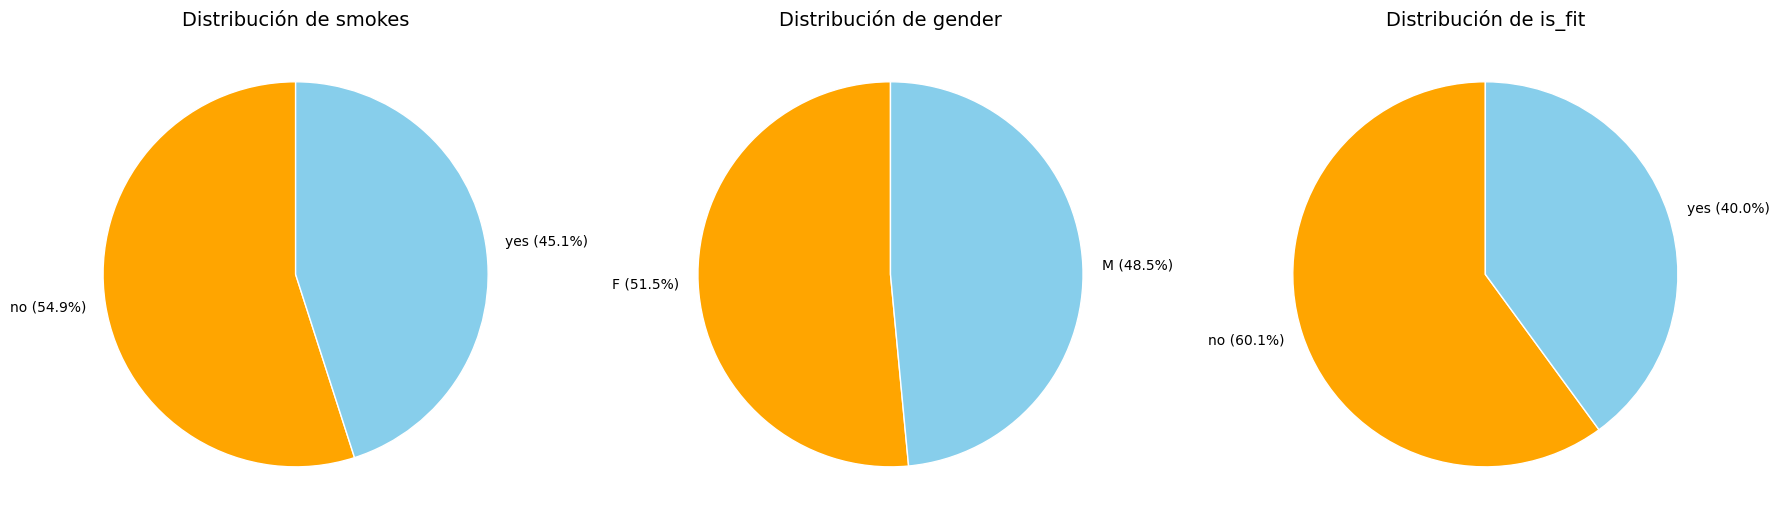

In [20]:
colors = ["orange", "skyblue"]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# ---- FIGURA 1: smokes ----
smokes_counts = df["smokes"].value_counts()
axes[0].pie(smokes_counts, 
            labels=[f"{cat} ({val/len(df)*100:.1f}%)" for cat, val in zip(smokes_counts.index, smokes_counts.values)],
            autopct=None, 
            startangle=90, 
            colors=colors, 
            wedgeprops={'edgecolor': 'white'})
axes[0].set_title("Distribución de smokes", fontsize=14)

# ---- FIGURA 2: gender ----
gender_counts = df["gender"].value_counts()
axes[1].pie(gender_counts, 
            labels=[f"{cat} ({val/len(df)*100:.1f}%)" for cat, val in zip(gender_counts.index, gender_counts.values)],
            autopct=None, 
            startangle=90, 
            colors=colors, 
            wedgeprops={'edgecolor': 'white'})
axes[1].set_title("Distribución de gender", fontsize=14)

# ---- FIGURA 3: is_fit ----
isfit_counts = df["is_fit"].value_counts()
axes[2].pie(isfit_counts, 
            labels=[f"{cat} ({val/len(df)*100:.1f}%)" for cat, val in zip(isfit_counts.index, isfit_counts.values)],
            autopct=None, 
            startangle=90, 
            colors=colors, 
            wedgeprops={'edgecolor': 'white'})
axes[2].set_title("Distribución de is_fit", fontsize=14)

plt.tight_layout()
plt.show()

### Interpretación de las Variables Binarias:

- En cuanto al hábito de fumar, se observa que el 54.9% de las personas no fuma, frente al 45.1% que sí lo hace, con una diferencia moderada entre ambos grupos (1,099 vs. 901 individuos).

- En la variable género, la distribución es bastante equilibrada, con un 51.5% de mujeres y un 48.5% de hombres (1,030 vs. 970 personas).

- Por último, en cuanto a la condición física, un 60.1% de los participantes no se considera en forma, mientras que el 40% sí lo está (1,201 vs. 799 personas), evidenciando una mayor diferencia entre categorías respecto a las otras variables.

- En conjunto, estos resultados permiten apreciar que las proporciones se mantienen cercanas al equilibrio en smokes y gender, pero en is_fit predomina claramente la categoría “no”.

## Variables Númericas Discretas

Se visualiza algunos estadísticos descriptivos para las variables númericas discretas.

In [21]:
discrete_numeric_cols = df.select_dtypes(include="int64").columns
df[discrete_numeric_cols].describe()

,age,height_cm,weight_kg
count,2000.000000,2000.00000,2000.000000
mean,49.114000,174.53300,82.910000
std,17.926564,14.37175,23.058247
min,18.000000,150.00000,30.000000
25%,34.000000,162.00000,64.000000
50%,49.000000,174.00000,83.000000
75%,65.000000,187.00000,102.000000
max,79.000000,199.00000,159.000000


### Interpretación de las Variables Númericas Discretas:

- En cuanto a age, la edad de los participantes oscila entre 18 y 79 años, con la mayoría concentrada entre 34 y 65 años.

- La estatura (height_cm) varía entre 150 y 199 cm, siendo más común observar valores en el rango de 162 a 187 cm.

- Finalmente, el peso (weight_kg) presenta un rango amplio de 30 a 159 kg, con mayor concentración entre 64 y 102 kg.

---------------------


Se genera un histograma para visualizar la distribución de frecuencias y la dispersión de los datos. Además se evalua:

- Asimetría:

skew = 0: Distribución simétrica (valores aceptables skew ∈(−1,1)).

skew > 0: Mayor peso en la cola izquierda de la distribución (sesgo positivo).

skew < 0: Mayor peso en la cola derecha de la distribución (sesgo negativo).

- Kurtosis: Determina si una distribución tiene colas gruesas con respecto a la distribución normal. Proporciona información sobre la forma de una distribución de frecuencias.

kurtosis = 3: se denomina mesocúrtica (distribución normal).

kurtosis < 3: se denomina platicúrtica (distribución con colas menos gruesas que la normal).

kurtosis > 3: se denomina leptocúrtica (distribución con colas más gruesas que la normal) y significa que trata de producir más valores atípicos que la distribución normal.

Variable: age
Kurtosis: 1.83
Skew: -0.04
----------------------------------------


c:\Users\johan\miniconda3\envs\ml_venv\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\johan\miniconda3\envs\ml_venv\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


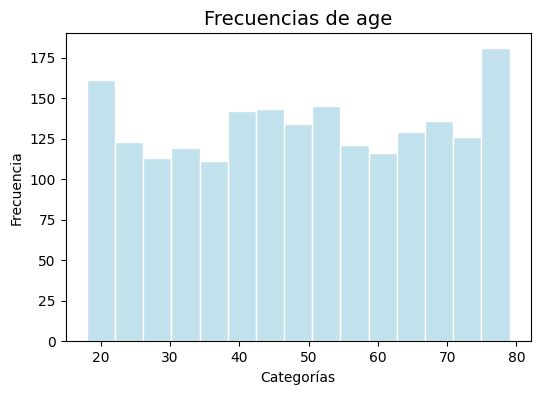

Variable: height_cm
Kurtosis: 1.81
Skew: 0.01
----------------------------------------


c:\Users\johan\miniconda3\envs\ml_venv\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\johan\miniconda3\envs\ml_venv\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


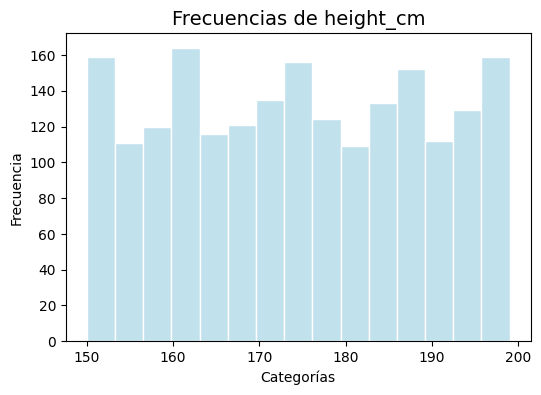

c:\Users\johan\miniconda3\envs\ml_venv\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\johan\miniconda3\envs\ml_venv\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


Variable: weight_kg
Kurtosis: 2.75
Skew: 0.22
----------------------------------------


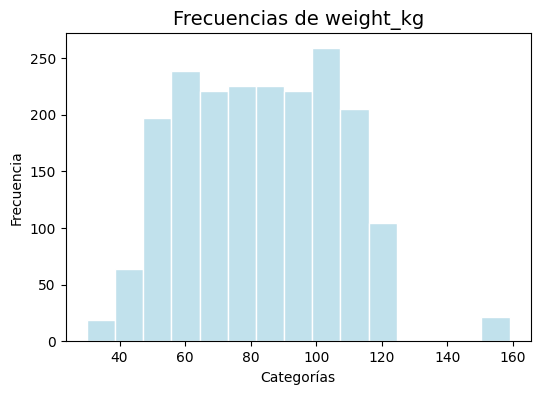

In [22]:
numeric_cols = df.select_dtypes(include=["int64"])

for col in numeric_cols:
    # Calcular skew y kurtosis
    col_skew = skew(df[col].dropna())
    col_kurt = kurtosis(df[col].dropna(), fisher=False)  # fisher=False para que 3 sea normal

    print(f"Variable: {col}")
    print(f"Kurtosis: {col_kurt:.2f}")
    print(f"Skew: {col_skew:.2f}")
    print("-"*40)
    
    # Histograma de frecuencias
    plt.figure(figsize=(6,4))
    sns.histplot(df[col].dropna(), bins=15, kde=False, color="lightblue", edgecolor="white")
    plt.title(f"Frecuencias de {col}", fontsize=14)
    plt.xlabel("Categorías")
    plt.ylabel("Frecuencia")
    plt.show()


### Análisis de los Valores de Asimetría (Skew) y Curtosis (Kurtosis)

#### Interpretación de **age**

##### Asimetría (Skew)

* **Valor:** $-0.04$
* **Interpretación:** El valor de la asimetría es muy cercano a cero ($-0.04$), y se encuentra dentro del rango aceptable de $(-1, 1)$. Esto indica que la distribución de las edades es **prácticamente simétrica**. La pequeña asimetría negativa sugiere una ligera tendencia a que la cola izquierda sea un poco más larga, pero es tan mínima que la distribución se considera simétrica.

##### Curtosis (Kurtosis)

* **Valor:** $1.83$
* **Interpretación:** El valor de la curtosis es $1.83$, que es **menor que 3**. Esto significa que la distribución es **platicúrtica**. Una distribución platicúrtica tiene colas más delgadas que una distribución normal, lo que a su vez sugiere que hay **menos valores atípicos** o *outliers* en los extremos de la distribución de lo que se esperaría en una distribución normal. En el contexto de este gráfico, significa que no hay una gran concentración de valores en la parte central, sino que las frecuencias se extienden de manera más uniforme a lo largo de las diferentes categorías de edad, como se puede ver en la distribución casi plana del gráfico.

#### Interpretación de **height**

##### Asimetría (Skew)
* **Valor:** $0.01$
* **Interpretación:** El valor de asimetría es muy cercano a **cero**, y está dentro del rango aceptable de $(-1, 1)$, lo que confirma que la distribución de las alturas es **simétrica**. Esto significa que los datos se distribuyen de manera equilibrada a ambos lados de la media, sin un sesgo significativo hacia valores más altos o más bajos.

##### Curtosis (Kurtosis)
* **Valor:** $1.81$
* **Interpretación:** El valor de curtosis es $1.81$, que es **menor que 3**. Por lo tanto, la distribución es **platicúrtica**. Esto indica que las colas de la distribución son menos gruesas que las de una distribución normal, sugiriendo que hay **menos valores atípicos** extremos. En el contexto de las alturas, esto significa que la variabilidad de los datos es baja y que las alturas de las personas se encuentran en un rango más concentrado, sin una gran cantidad de individuos extremadamente altos o extremadamente bajos. El histograma plano también es una característica común de las distribuciones platicúrticas.

#### Interpretación de **weight**

##### Asimetría (Skew)
* **Valor:** $0.22$
* **Interpretación:** El valor de asimetría es $0.22$, un valor **positivo** que está dentro del rango aceptable $(-1, 1)$. Aunque el valor es bajo, la asimetría positiva sugiere que la distribución tiene un **sesgo hacia la derecha**. Esto significa que la cola de la distribución en el lado de los pesos más altos es más larga. Este sesgo se debe principalmente a la presencia de un valor atípico o *outlier* que "tira" de la media hacia la derecha. La mayoría de los datos se agrupan en los valores más bajos, mientras que hay una menor cantidad de individuos con pesos muy altos.

##### Curtosis (Kurtosis)
* **Valor:** $2.75$
* **Interpretación:** El valor de curtosis es $2.75$, que es **menor que 3**. Por lo tanto, la distribución es **platicúrtica**. Esto indica que las colas de la distribución son menos gruesas que las de una distribución normal. A pesar de la presencia de un valor atípico, la distribución de los datos, en general, no produce una gran cantidad de valores extremos, lo cual es típico de una distribución platicúrtica. Esto sugiere que la variabilidad de los datos no es excesivamente amplia.

### Variables Númericas Continuas

Se visualiza algunos estadísticos descriptivos para las variables númericas continuas.


In [23]:
float_cols = df.select_dtypes(include='float')
summary = float_cols.describe().T 
summary

,count,mean,std,min,25%,50%,75%,max
heart_rate,2000.0,70.272813,11.796247,45.0,62.1000,70.250,78.425,102.9125
blood_pressure,2000.0,119.895450,14.537333,90.0,109.7000,120.000,129.800,159.9500
sleep_hours,2000.0,7.509700,1.433800,4.0,6.6000,7.500,8.400,11.1000
nutrition_quality,2000.0,5.035140,2.864156,0.0,2.5475,5.065,7.470,10.0000
activity_index,2000.0,2.999040,1.136383,1.0,2.0375,2.980,3.950,4.9900


#### Interpretación de las Variables Númericas Continuas:

Los resúmenes estadísticos revelan que todas las variables continuas, ritmo cardíaco, presión sanguínea, horas de sueño, calidad de la nutrición e índice de actividad. Tienen distribuciones altamente simétricas, lo que se evidencia en la proximidad de los valores de la media y la mediana en cada caso. El ritmo cardíaco (media 70.27, mediana 70.25), la presión sanguínea (media 119.9, mediana 120.0), las horas de sueño (media 7.51, mediana 7.50), la calidad de la nutrición (media 5.035, mediana 5.065) y el índice de actividad (media 2.999, mediana 2.980) muestran una consistencia notable en sus valores centrales. Esta uniformidad sugiere que los datos no están sesgados hacia valores extremos y que los valores atípicos, de existir, no tienen un impacto significativo en la tendencia central de las variables, lo que indica que los datos son homogéneos y representativos.
Estos resultados ofrecen una visión general del rango y concentración de cada variable.


--------------------------

Se genera un histograma para visualizar la distribución de frecuencias y la dispersión de los datos. Además se evalua:

- Asimetría:

skew = 0: Distribución simétrica (valores aceptables skew ∈(−1,1)
).
skew > 0: Mayor peso en la cola izquierda de la distribución (sesgo positivo).
skew < 0: Mayor peso en la cola derecha de la distribución (sesgo negativo).

- Kurtosis: Determina si una distribución tiene colas gruesas con respecto a la distribución normal. Proporciona información sobre la forma de una distribución de frecuencias.

kurtosis = 3: se denomina mesocúrtica (distribución normal).
kurtosis < 3: se denomina platicúrtica (distribución con colas menos gruesas que la normal).
kurtosis > 3: se denomina leptocúrtica (distribución con colas más gruesas que la normal) y significa que trata de producir más valores atípicos que la distribución normal.

Variable: heart_rate
Kurtosis: 2.74
Skew: 0.11
----------------------------------------


c:\Users\johan\miniconda3\envs\ml_venv\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\johan\miniconda3\envs\ml_venv\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


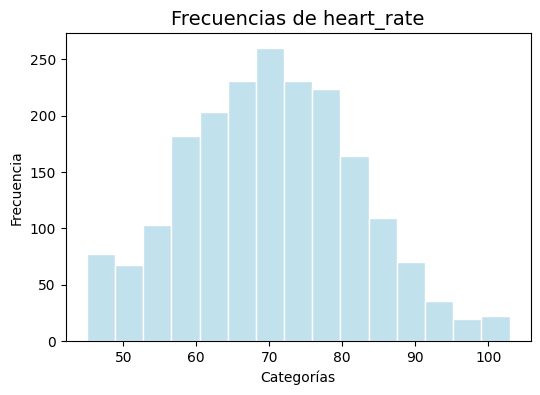

Variable: blood_pressure
Kurtosis: 2.66
Skew: 0.08
----------------------------------------


c:\Users\johan\miniconda3\envs\ml_venv\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\johan\miniconda3\envs\ml_venv\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


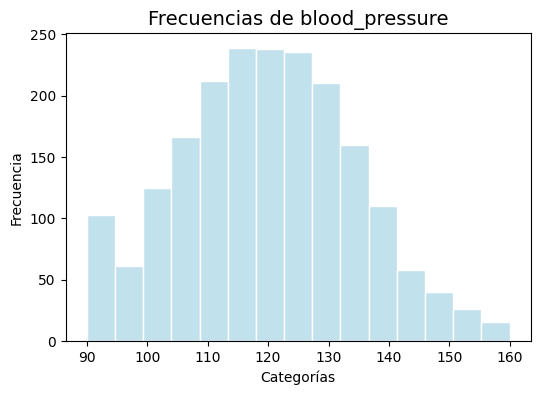

Variable: sleep_hours
Kurtosis: 2.95
Skew: -0.05
----------------------------------------


c:\Users\johan\miniconda3\envs\ml_venv\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\johan\miniconda3\envs\ml_venv\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


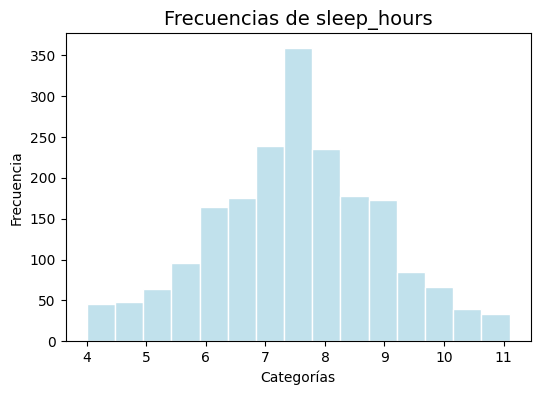

c:\Users\johan\miniconda3\envs\ml_venv\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\johan\miniconda3\envs\ml_venv\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


Variable: nutrition_quality
Kurtosis: 1.80
Skew: 0.01
----------------------------------------


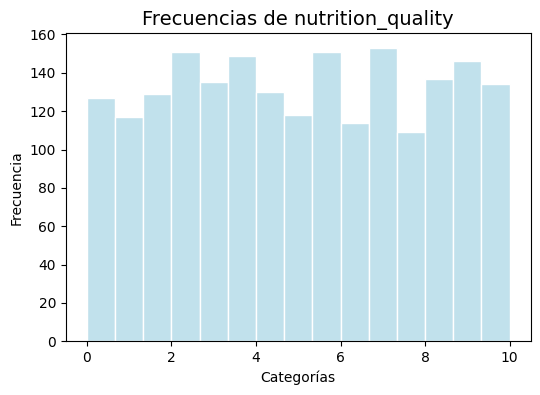

Variable: activity_index
Kurtosis: 1.85
Skew: 0.04
----------------------------------------


c:\Users\johan\miniconda3\envs\ml_venv\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\johan\miniconda3\envs\ml_venv\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


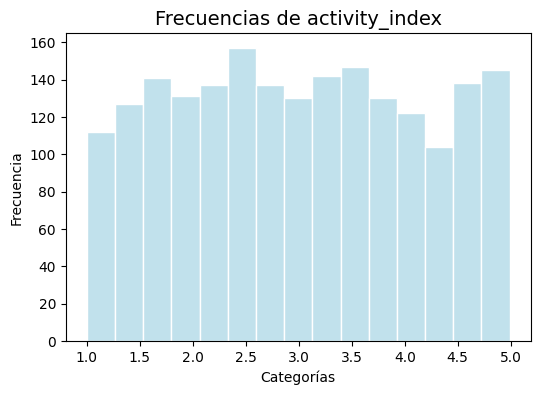

In [24]:
numeric_cols2 = df.select_dtypes(include=["float64"])

for col in numeric_cols2:
    # Calcular skew y kurtosis
    col_skew = skew(df[col].dropna())
    col_kurt = kurtosis(df[col].dropna(), fisher=False)  # fisher=False para que 3 sea normal

    print(f"Variable: {col}")
    print(f"Kurtosis: {col_kurt:.2f}")
    print(f"Skew: {col_skew:.2f}")
    print("-"*40)
    
    # Histograma de frecuencias
    plt.figure(figsize=(6,4))
    sns.histplot(df[col].dropna(), bins=15, kde=False, color="lightblue", edgecolor="white")
    plt.title(f"Frecuencias de {col}", fontsize=14)
    plt.xlabel("Categorías")
    plt.ylabel("Frecuencia")
    plt.show()


### Análisis de los Valores de Asimetría (Skew) y Curtosis (Kurtosis)

#### Variable **heart_rate**

##### Asimetría (Skew)
* **Valor:** $0.11$
* **Interpretación:** Con un valor de asimetría de $0.11$, la distribución es **casi perfectamente simétrica**, ya que este valor es muy cercano a cero y cae dentro del rango aceptable de $(-1, 1)$. Esto significa que la distribución de las frecuencias cardíacas es equilibrada, sin un sesgo significativo hacia valores más altos o más bajos.


##### Curtosis (Kurtosis)
* **Valor:** $2.74$
* **Interpretación:** El valor de curtosis es $2.74$, que es **menor que 3**. Esto clasifica la distribución como **platicúrtica**. Una distribución platicúrtica tiene colas más delgadas que una distribución normal, lo que sugiere que hay **menos valores atípicos** o extremos de lo que se esperaría. En este contexto, indica que la mayoría de las frecuencias cardíacas se encuentran cerca del promedio, sin una gran cantidad de personas con ritmos cardíacos extremadamente altos o bajos.

---

#### Variable **Blood_pressure

##### Asimetría (Skew)
* **Valor:** $0.08$
* **Interpretación:** El valor de asimetría es muy cercano a cero ($0.08$), lo que significa que la distribución es **prácticamente simétrica**. Al estar dentro del rango aceptable de $(-1, 1)$, se puede concluir que no hay un sesgo significativo hacia valores de presión arterial ni muy altos ni muy bajos. Los datos se distribuyen de manera equilibrada a ambos lados de la media.


##### Curtosis (Kurtosis)
* **Valor:** $2.66$
* **Interpretación:** La curtosis de $2.66$ es **menor que 3**, lo que la clasifica como una distribución **platicúrtica**. Esto indica que las colas de la distribución son más ligeras que las de una distribución normal. En el contexto de la presión arterial, esto sugiere que hay **menos valores atípicos** o extremos de lo que se esperaría. La mayoría de las mediciones de presión arterial se encuentran en un rango relativamente estrecho y concentrado, con pocos individuos que presenten lecturas extremadamente altas o bajas.

---

#### Variable sleep_hours

##### Asimetría (Skew)
* **Valor:** $-0.05$
* **Interpretación:** El valor de asimetría es muy cercano a cero ($-0.05$), lo que indica que la distribución es **prácticamente simétrica**. Al estar dentro del rango aceptable de $(-1, 1)$, se puede concluir que no hay un sesgo significativo hacia un mayor o menor número de horas de sueño. Los datos se distribuyen de manera equilibrada a ambos lados de la media.


##### Curtosis (Kurtosis)
* **Valor:** $2.95$
* **Interpretación:** Con un valor de curtosis de $2.95$, que es **menor que 3**, la distribución es **platicúrtica**. Esto sugiere que las colas de la distribución son menos gruesas que las de una distribución normal, lo que indica que hay **menos valores atípicos** o extremos. En este caso, esto significa que no hay una gran cantidad de personas que duerman muy pocas horas o muchísimas horas; la mayoría de los datos se concentran en un rango más estrecho y esperado de horas de sueño.

---

#### Varaible **Nutrition_cuality**

##### Asimetría (Skew)
* **Valor:** $0.01$
* **Interpretación:** El valor de asimetría es muy cercano a cero ($0.01$), lo que indica una distribución **prácticamente simétrica**. Esto significa que los datos están distribuidos de forma equilibrada, sin un sesgo significativo hacia valores más altos o más bajos de calidad nutricional.


##### Curtosis (Kurtosis)
* **Valor:** $1.80$
* **Interpretación:** El valor de curtosis es $1.80$, que es **menor que 3**. Por lo tanto, la distribución es **platicúrtica**. Esto significa que las colas de la distribución son menos gruesas que las de una distribución normal. En este contexto, esto sugiere que no hay una alta concentración de datos en los extremos, lo que indica **menos valores atípicos** de lo que se esperaría en una distribución normal. La distribución plana del histograma es un rasgo característico de una distribución platicúrtica.

---

#### Variable **Activity_index**

##### Asimetría (Skew)
* **Valor:** $0.04$
* **Interpretación:** El valor de asimetría de $0.04$ está muy cerca de cero, lo que indica que la distribución es **prácticamente simétrica**. Al estar dentro del rango aceptable de $(-1, 1)$, no hay un sesgo significativo hacia valores más altos o más bajos del índice de actividad.


##### Curtosis (Kurtosis)
* **Valor:** $1.85$
* **Interpretación:** El valor de curtosis es $1.85$, que es **menor que 3**. Por lo tanto, la distribución es **platicúrtica**. Esto significa que las colas de la distribución son menos gruesas que las de una distribución normal, lo que sugiere que hay **menos valores atípicos** o extremos. La distribución uniforme de los datos en el gráfico confirma esta interpretación, ya que no hay un pico central pronunciado ni colas gruesas.


---


Se genera un un boxplot para visualizar la distribución e identificar outliers (puntos fuera de los bigotes) y la dispersión de los datos. Además se evalua:

Coeficiente de Variación: es una medida estadística que se utiliza para evaluar la variabilidad relativa de una muestra o población en relación con su media. Se calcula como la desviación estándar de los datos dividida por la media, y se expresa como un porcentaje multiplicado por 100 para facilitar su interpretación.

Columna: heart_rate
El coeficiente de variación es: 16.79%



c:\Users\johan\miniconda3\envs\ml_venv\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


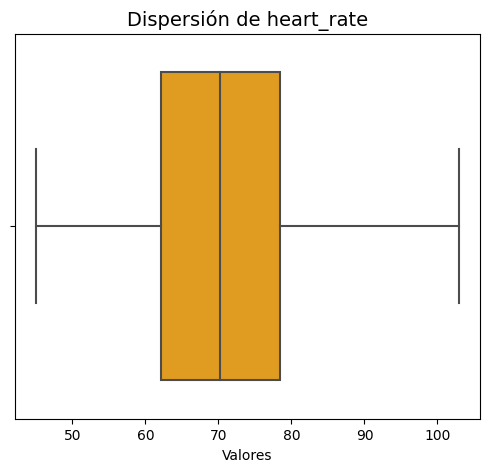

Columna: blood_pressure
El coeficiente de variación es: 12.13%



c:\Users\johan\miniconda3\envs\ml_venv\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


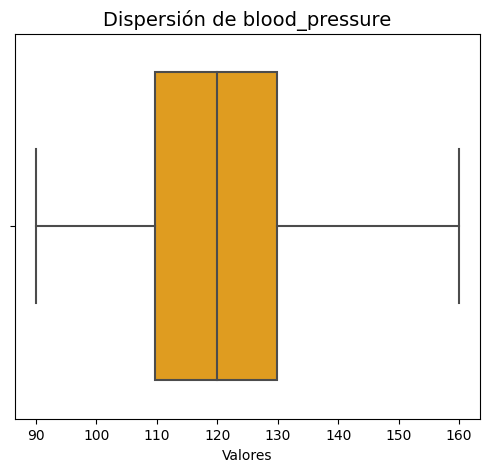

Columna: sleep_hours
El coeficiente de variación es: 19.09%



c:\Users\johan\miniconda3\envs\ml_venv\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


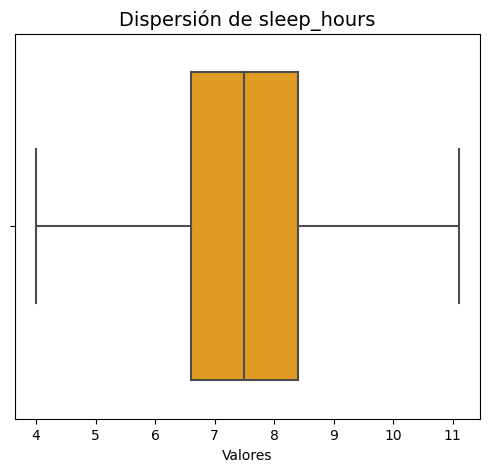

Columna: nutrition_quality
El coeficiente de variación es: 56.88%



c:\Users\johan\miniconda3\envs\ml_venv\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


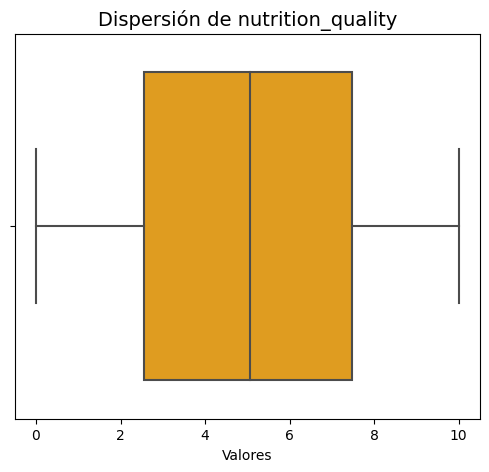

Columna: activity_index
El coeficiente de variación es: 37.89%



c:\Users\johan\miniconda3\envs\ml_venv\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


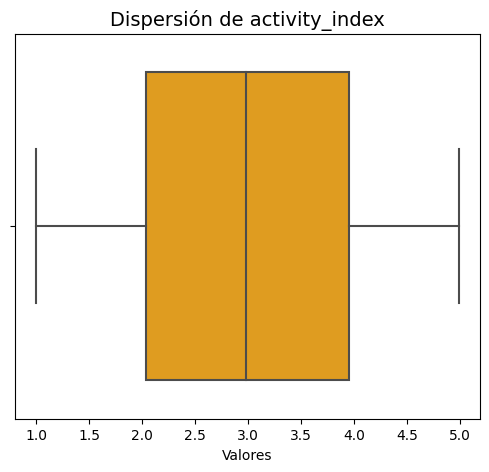

In [25]:
for i in range(3, 8):
    nombre_col = df.columns[i]
    
    # Calcular media y desviación estándar ignorando NaN
    media = df[nombre_col].mean(skipna=True)
    desviacion = df[nombre_col].std(skipna=True)
    
    # Coeficiente de variación
    coef_variacion = (desviacion / media) * 100
    print(f"Columna: {nombre_col}")
    print(f"El coeficiente de variación es: {coef_variacion:.2f}%\n")
    
    # Boxplot
    plt.figure(figsize=(6,5))
    sns.boxplot(x=df[nombre_col], color="orange")
    plt.title(f"Dispersión de {nombre_col}", fontsize=14)
    plt.xlabel("Valores")
    plt.show()


### Interpretación de las Variables Númericas Continuas:

- El coeficiente de variación del ritmo cardíaco es de 16.79%, lo que indica una baja dispersión de los datos. Esto significa que la mayoría de los valores de ritmo cardíaco están muy cerca de la media. El diagrama de caja y bigotes corrobora esto, mostrando una caja estrecha y la ausencia de valores atípicos, lo que confirma que los datos son muy consistentes.

- El coeficiente de variación para la presión sanguínea es de 12.13%, lo que indica una baja dispersión y una alta consistencia en los datos. El diagrama de caja y bigotes corrobora esto, mostrando que la mitad de los datos se agrupan en un rango estrecho y que no hay valores atípicos, lo que refuerza la idea de que la presión sanguínea es bastante uniforme en esta población.

- El coeficiente de variación para las horas de sueño es de 19.09%, lo que indica una baja dispersión en los datos. El diagrama de caja confirma esta consistencia, mostrando una caja relativamente estrecha y la ausencia de valores atípicos, lo que sugiere que la mayoría de los individuos duermen una cantidad de horas similar, con poca variación.

- El coeficiente de variación para la calidad de la nutrición es de 56.88%. Este valor, al ser superior a 50%, indica una dispersión moderada-alta en los datos. A diferencia de los gráficos anteriores, la caja del diagrama de caja es más ancha, lo que visualmente confirma que el 50% de los datos centrales tienen un rango más amplio. Esto sugiere que hay una mayor variabilidad en la calidad de la nutrición entre los individuos, con valores más dispersos alrededor de la media y la mediana.

- El coeficiente de variación del índice de actividad es de 37.89%. Este valor indica una dispersión moderada de los datos, ya que es significativamente mayor que los de las variables fisiológicas (ritmo cardíaco, presión sanguínea, horas de sueño), pero menor que el de la calidad de la nutrición. El diagrama de caja y bigotes corrobora esto, mostrando una caja más ancha que las primeras variables, lo que sugiere que hay una mayor variabilidad en los niveles de actividad entre los individuos. Sin embargo, no se aprecian valores atípicos que distorsionen la distribución.

# Análisis Bivariado

El análisis bivariado es la segunda fase del análisis exploratorio de datos. Se enfoca en las relaciones entre dos variables para obtener datos estadísticos sobre sus influencias mutuas.

---

Se generan graficos de barras para analizar la relación entre el conjunto de variables binarias y la variable estado de forma con el fin de identificar qué variables binarias están asociadas en mayores proporciones.

c:\Users\johan\miniconda3\envs\ml_venv\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\johan\miniconda3\envs\ml_venv\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\johan\miniconda3\envs\ml_venv\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


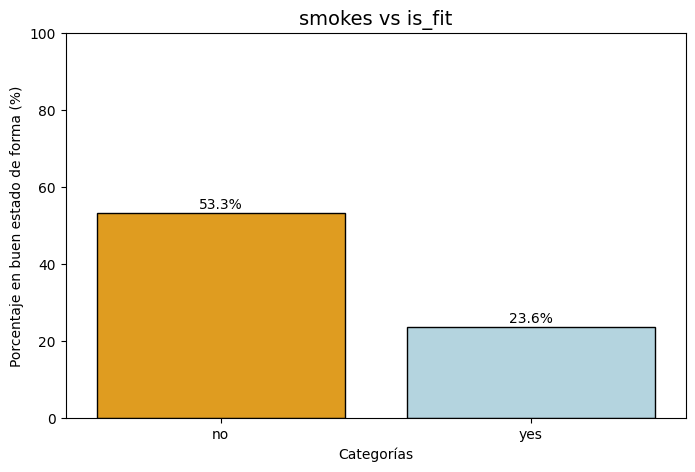

c:\Users\johan\miniconda3\envs\ml_venv\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\johan\miniconda3\envs\ml_venv\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\johan\miniconda3\envs\ml_venv\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


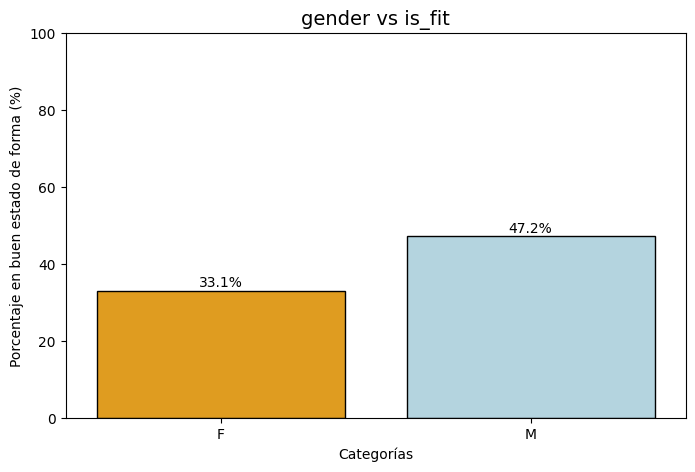

In [26]:
for i in range(8, 10):
    nombre_col = df.columns[i]
    
    # Agrupar y calcular porcentaje
    df_summary = (
        df.groupby(nombre_col)['is_fit']
        .apply(lambda x: (x == "yes").mean() * 100)
        .reset_index(name='pct_yes')
    )
    
    # Barplot
    plt.figure(figsize=(8,5))
    sns.barplot(
        data=df_summary,
        x=nombre_col,
        y='pct_yes',
        palette=['orange', 'lightblue'],
        edgecolor='black'
    )
    
    # Agregar etiquetas de porcentaje
    for index, row in df_summary.iterrows():
        plt.text(index, row['pct_yes'] + 1, f"{row['pct_yes']:.1f}%", 
                 ha='center', color='black')
    
    plt.ylim(0, 100)
    plt.title(f"{nombre_col} vs is_fit", fontsize=14)
    plt.xlabel("Categorías")
    plt.ylabel("Porcentaje en buen estado de forma (%)")
    plt.show()


### Interpretación:

Estos gráficos de barras comparan el porcentaje de personas en buen estado de forma (is_fit) con dos variables categóricas: género (gender) y si fuman (smokes).

- El gráfico de barras muestra la relación entre fumar y estar en buena forma física. La barra naranja, que representa a los no fumadores (“no”), indica que el 53.3% de este grupo está en buena forma física. En contraste, la barra azul, que representa a los fumadores (“yes”), muestra que solo el 23.6% de ellos está en buena forma física. Esto sugiere que hay una relación negativa entre fumar y el buen estado de forma, ya que el porcentaje de personas en buena forma física es significativamente más alto entre los no fumadores que entre los fumadores.

- El gráfico de barras muestra una clara relación entre fumar y el estado de forma física. El 53.3% de las personas que no fuman están en buen estado de forma, mientras que solo el 23.6% de las personas que sí fuman lo están. Esto indica que hay una asociación negativa significativa: la probabilidad de estar en buen estado físico es más del doble entre los no fumadores que entre los fumadores.

---

Se generan graficos de barras para analizar la relación entre variables númericas discretas y el estado de forma en la población estudiada. Con el fin de identificar qué variables presentan mayores proporciones.

c:\Users\johan\miniconda3\envs\ml_venv\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\johan\miniconda3\envs\ml_venv\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\johan\miniconda3\envs\ml_venv\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


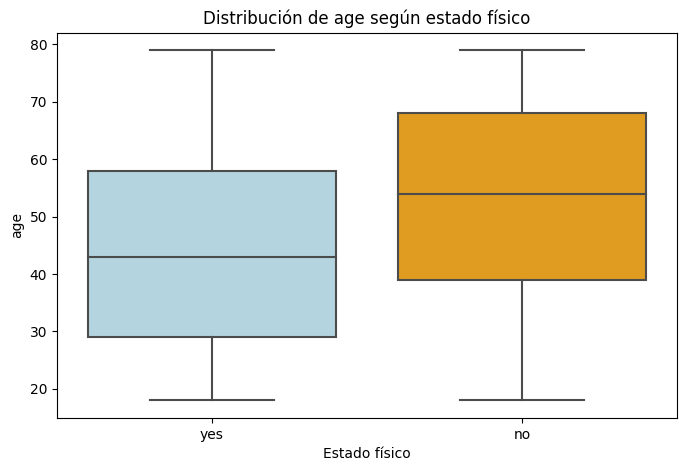

c:\Users\johan\miniconda3\envs\ml_venv\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\johan\miniconda3\envs\ml_venv\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\johan\miniconda3\envs\ml_venv\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


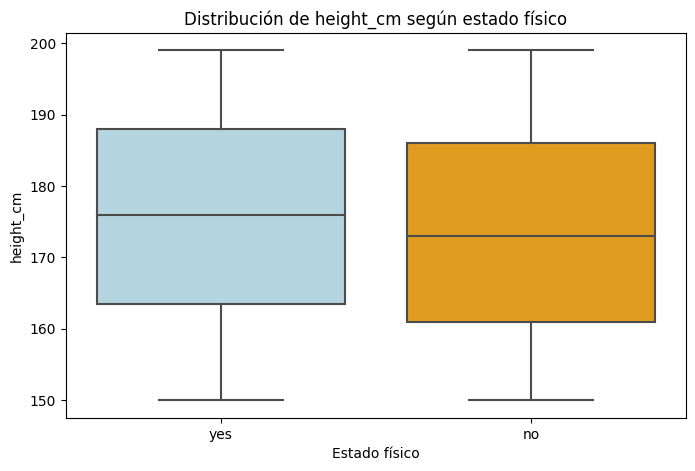

c:\Users\johan\miniconda3\envs\ml_venv\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\johan\miniconda3\envs\ml_venv\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\johan\miniconda3\envs\ml_venv\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


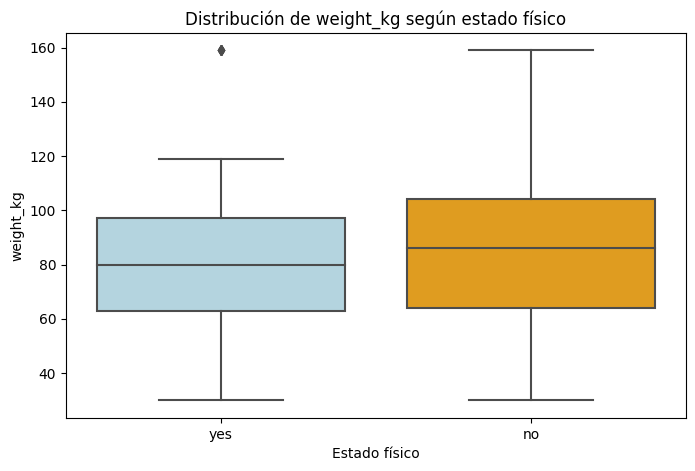

In [27]:
integer_cols = df.select_dtypes(include='int').columns  # selecciona solo columnas enteras

for col in integer_cols:
    plt.figure(figsize=(8,5))
    sns.boxplot(x='is_fit', y=col, data=df, palette=['lightblue','orange'])
    plt.title(f'Distribución de {col} según estado físico')
    plt.xlabel('Estado físico')
    plt.ylabel(col)
    plt.show()


### **Medidas y Análisis de los Gráficos**

#### **age vs is_fit**

##### **Mediana**
La línea central en la caja representa la mediana de la edad para cada grupo.
* **Grupo "yes" (sí):** La mediana está alrededor de **43 años**.
* **Grupo "no":** La mediana se encuentra aproximadamente en **54 años**.

Esto indica que el grupo con un buen estado físico es, en promedio, más joven.

##### **Rangos Intercuartílicos (IQR)**
La caja de cada grupo representa el **rango intercuartílico (IQR)**, que contiene el 50% central de los datos.
* **Grupo "yes":** La caja va de aproximadamente 28 a 58 años.
* **Grupo "no":** La caja va de aproximadamente 40 a 68 años.

Ambos grupos tienen una dispersión de datos similar en su mitad central.

##### **Valores Atípicos (Outliers)**
No se observan puntos atípicos (outliers) fuera de los bigotes en ninguno de los grupos. Esto sugiere que no hay individuos con edades extremadamente jóvenes o viejas en la muestra.

---

#### height vs is_fit

##### Mediana
* **Grupo "yes" (sí):** La línea central de la caja, que representa la mediana, se ubica en aproximadamente **176 cm**.
* **Grupo "no":** La mediana se encuentra en aproximadamente **173 cm**.

Aunque el grupo "yes" tiene una mediana ligeramente mayor, la diferencia es mínima, lo que sugiere que la altura no es un factor que distinga significativamente entre ambos grupos.

##### Rango Intercuartílico (IQR)
La caja de cada grupo muestra el **rango intercuartílico (IQR)**, el cual contiene el 50% central de los datos.
* **Grupo "yes":** El IQR abarca desde aproximadamente **163 cm hasta 188 cm**.
* **Grupo "no":** El IQR va desde aproximadamente **160 cm hasta 186 cm**.

La dispersión de los datos en la mitad central de la distribución es similar para ambos grupos.

##### Valores Atípicos
* No se observan **valores atípicos** (puntos fuera de los bigotes) en ninguno de los dos grupos. Esto indica que no hay personas con estaturas extremadamente altas o bajas en la muestra que se salgan del patrón general.

En conclusión, este gráfico muestra que la distribución de la altura es muy similar en ambos grupos de estado físico, con medianas y rangos intercuartílicos muy parecidos.

---

#### weight vs is_fit

##### Mediana
* **Grupo "yes" (sí):** La línea central de la caja, que representa la mediana, se ubica en aproximadamente **80 kg**.
* **Grupo "no":** La mediana se encuentra en aproximadamente **86 kg**.

Esto indica que el grupo con un buen estado físico es, en promedio, más liviano que el grupo sin él, aunque la diferencia no es drástica.

##### Rango Intercuartílico (IQR)
La caja de cada grupo muestra el **rango intercuartílico (IQR)**, que contiene el 50% central de los datos.
* **Grupo "yes":** El IQR abarca desde aproximadamente **64 kg hasta 98 kg**.
* **Grupo "no":** El IQR va desde aproximadamente **65 kg hasta 104 kg**.

Ambos grupos tienen una dispersión de datos similar en su mitad central.

##### Valores Atípicos (Outliers)
* **Grupo "yes":** Se observa un **valor atípico** (un punto fuera del bigote superior) en el grupo con buen estado físico, con un peso alrededor de **160 kg**. Este punto representa un individuo que es significativamente más pesado que el resto del grupo.
* **Grupo "no":** No se observan valores atípicos.

En conclusión, este gráfico muestra una diferencia en el peso promedio entre ambos grupos, con el grupo con un buen estado físico siendo ligeramente más liviano. La presencia de un valor atípico en el grupo "yes" sugiere un caso inusual que se desvía del patrón general de peso en ese grupo.

---

Se generan histogramas para analizar la relación entre variables númericas continuas y el estado de forma en la población estudiada. Con el fin de identificar qué variables presentan mayores proporciones.

c:\Users\johan\miniconda3\envs\ml_venv\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\johan\miniconda3\envs\ml_venv\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\johan\miniconda3\envs\ml_venv\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


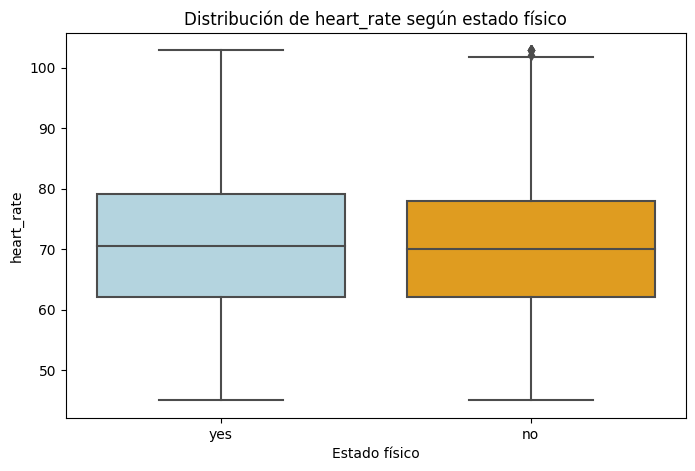

c:\Users\johan\miniconda3\envs\ml_venv\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\johan\miniconda3\envs\ml_venv\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\johan\miniconda3\envs\ml_venv\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


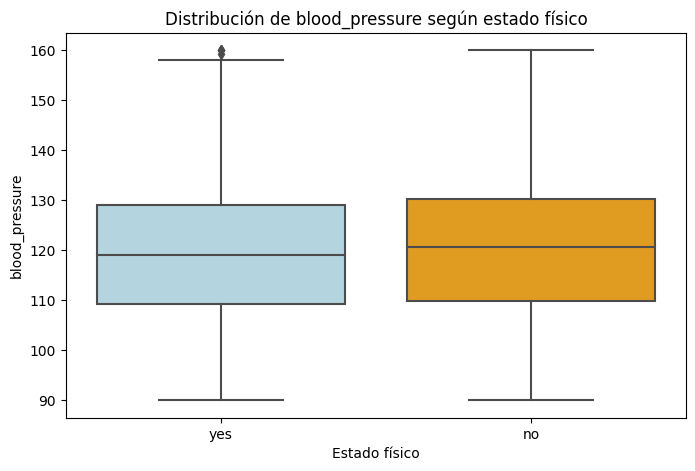

c:\Users\johan\miniconda3\envs\ml_venv\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\johan\miniconda3\envs\ml_venv\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\johan\miniconda3\envs\ml_venv\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


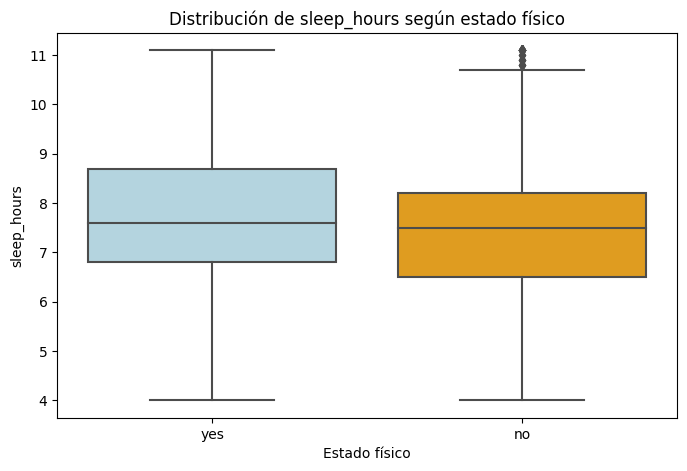

c:\Users\johan\miniconda3\envs\ml_venv\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\johan\miniconda3\envs\ml_venv\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\johan\miniconda3\envs\ml_venv\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


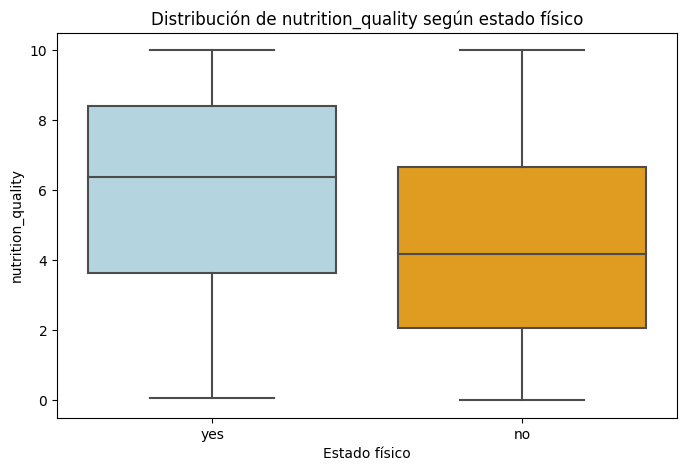

c:\Users\johan\miniconda3\envs\ml_venv\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\johan\miniconda3\envs\ml_venv\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\johan\miniconda3\envs\ml_venv\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


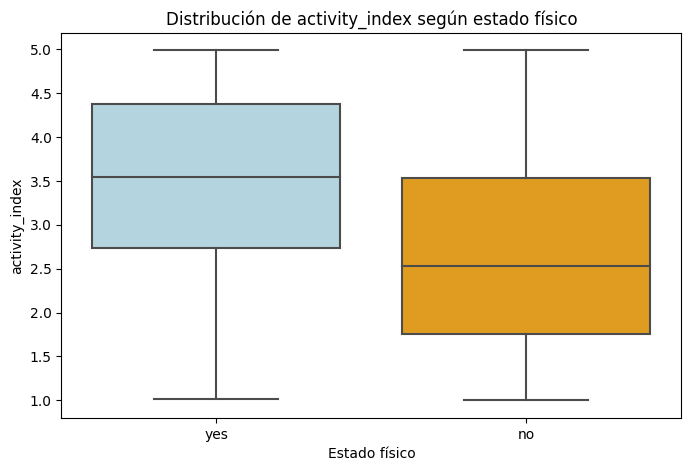

In [28]:

float_cols = df.select_dtypes(include='float').columns

for col in float_cols:
    plt.figure(figsize=(8,5))
    sns.boxplot(x='is_fit', y=col, data=df, palette=['lightblue','orange'])
    plt.title(f'Distribución de {col} según estado físico')
    plt.xlabel('Estado físico')
    plt.ylabel(col)
    plt.show()


# Analisis multivariado

El análisis multivariado nos permite examinar simultáneamente las relaciones entre múltiples variables, revelando patrones complejos que no son evidentes en los análisis univariados o bivariados.

Se genera un heatmap de correlación de Pearson el cual nos permitira visualizar relaciones de dos o mas variables de manera compacta, destacando asociaciones lineales fuertes (positivas o negativas) entre las variables numéricas del dataset, a demas, nos permitira detectar posibles multicolinealidades y o entender la estructura de los datos.

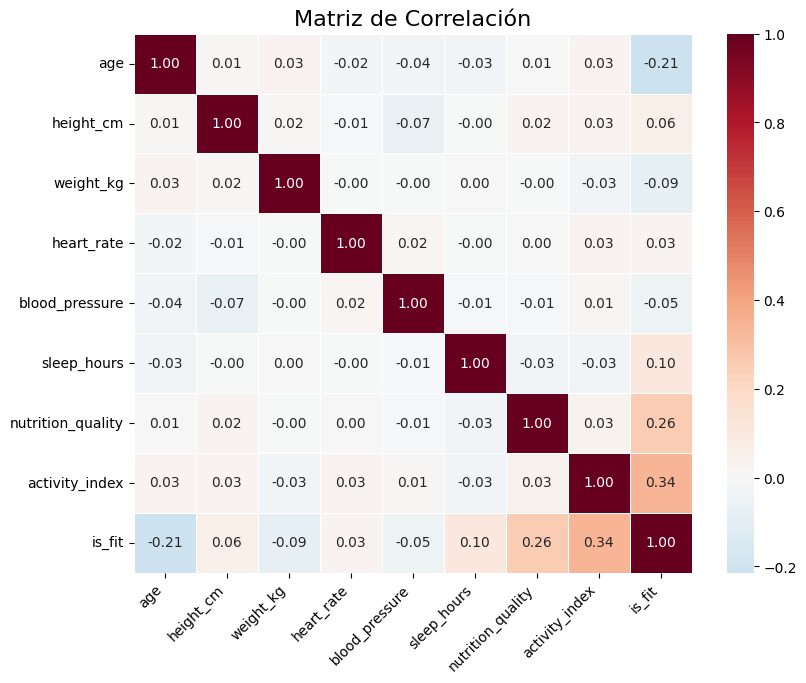

In [29]:
cols = ['age', 'height_cm', 'weight_kg', 'heart_rate', 
        'blood_pressure', 'sleep_hours', 
        'nutrition_quality', 'activity_index', 'is_fit']

df_cor = df[cols].copy()

# Convertir is_fit a 0/1
df_cor['is_fit'] = df_cor['is_fit'].apply(lambda x: 1 if x=="yes" else 0)

cor_matrix = df_cor.corr()

plt.figure(figsize=(9,7))
sns.heatmap(
    cor_matrix, 
    annot=True, 
    fmt=".2f", 
    cmap="RdBu_r",  # De azul (negativa) a rojo (positiva)
    center=0,
    linewidths=0.7,
    linecolor='white'
)
plt.title("Matriz de Correlación", fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.show()


### Interpretación

- La relación más fuerte con el estado de forma física (is_fit) se da con las siguientes variables:

Correlación positiva: Las variables que tienen la relación positiva más fuerte con estar en buena forma física son activity_index (0.34) y nutrition_quality (0.26). Esto significa que un mayor índice de actividad y una mejor calidad de la nutrición están asociados con una mayor probabilidad de estar en buena forma.
Correlación negativa: La variable que tiene la relación negativa más fuerte con estar en buena forma física es la edad (-0.21). Esto significa que, a mayor edad, la probabilidad de estar en buena forma física disminuye.
Las demás variables (altura, peso, ritmo cardíaco, horas de sueño y presión sanguínea) muestran correlaciones muy débiles con el estado de forma física, con valores cercanos a cero. Esto indica que no hay una relación lineal significativa entre estas variables y si una persona está en buena forma física o no.